<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/binnig_binarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [193]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
#dt=DecisionTreeRegressor()
from sklearn.linear_model import LinearRegression
dt=LinearRegression()

In [194]:
df=pd.read_csv("AmesHousing.csv")

In [195]:
df.sample(3)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1544,1545,910200080,30,RM,50.0,7000,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,126000
1458,1459,907254090,60,RL,75.0,11404,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,222500
51,52,528218150,20,RL,100.0,18494,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,199500


In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [197]:
df.isnull().sum()

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [199]:
df = df[['Year Built', 'Lot Area', 'Overall Qual', 'Gr Liv Area', 'SalePrice']]

In [200]:
x_test,x_train,y_test,y_train=train_test_split(df.drop('SalePrice', axis=1),df['SalePrice'],test_size=0.2,random_state=42)

In [201]:
dt.fit(x_train,y_train)
pred=dt.predict(x_test)
accuracy=r2_score(y_test,pred)
print(f"R2 score with original features: {accuracy}")

R2 score with original features: 0.7571330626265709


In [202]:
dt.fit(x_train,y_train)
pred=dt.predict(x_test)
accuracy=r2_score(y_test,pred)
print(f"R2 score with original features: {accuracy}")

R2 score with original features: 0.7571330626265709


In [203]:
dt.fit(x_train,y_train)
pred=dt.predict(x_test)
accuracy=r2_score(y_test,pred)
accuracy

0.7571330626265709

### check the result after binning

In [204]:
tf=ColumnTransformer(transformers=[
    ('year_built_bin',KBinsDiscretizer(n_bins=7,encode='ordinal',strategy='quantile'),['Year Built']),
    ('lot_area_bin',KBinsDiscretizer(n_bins=7,encode='ordinal',strategy='quantile'),['Lot Area']),
    ('gr_liv_area_bin',KBinsDiscretizer(n_bins=7,encode='ordinal',strategy='quantile'),['Gr Liv Area'])
], remainder='passthrough')

In [205]:
x_Train_tf=tf.fit_transform(x_train)
x_Test_tf=tf.transform(x_test)

In [206]:
dt.fit(x_Train_tf,y_train)
pred=dt.predict(x_Test_tf)
accuracy=r2_score(y_test,pred)
print(f"R2 score with binned features: {accuracy}")

R2 score with binned features: 0.7406282680204586


In [207]:
dt.fit(x_Train_tf,y_train)
pred=dt.predict(x_Test_tf)
accuracy=r2_score(y_test,pred)
print(f"R2 score with binned features: {accuracy}")

R2 score with binned features: 0.7406282680204586


In [208]:
dt.fit(x_Train_tf,y_train)
pred=dt.predict(x_Test_tf)
accuracy=r2_score(y_test,pred)
print(f"R2 score with binned features: {accuracy}")

R2 score with binned features: 0.7406282680204586


In [209]:
dt.fit(x_Train_tf,y_train)
pred=dt.predict(x_Test_tf)
accuracy=r2_score(y_test,pred)
accuracy

0.7406282680204586

In [212]:
df.skew().drop('SalePrice')

,0
Year Built,-0.604462
Lot Area,12.820898
Overall Qual,0.190634
Gr Liv Area,1.274110


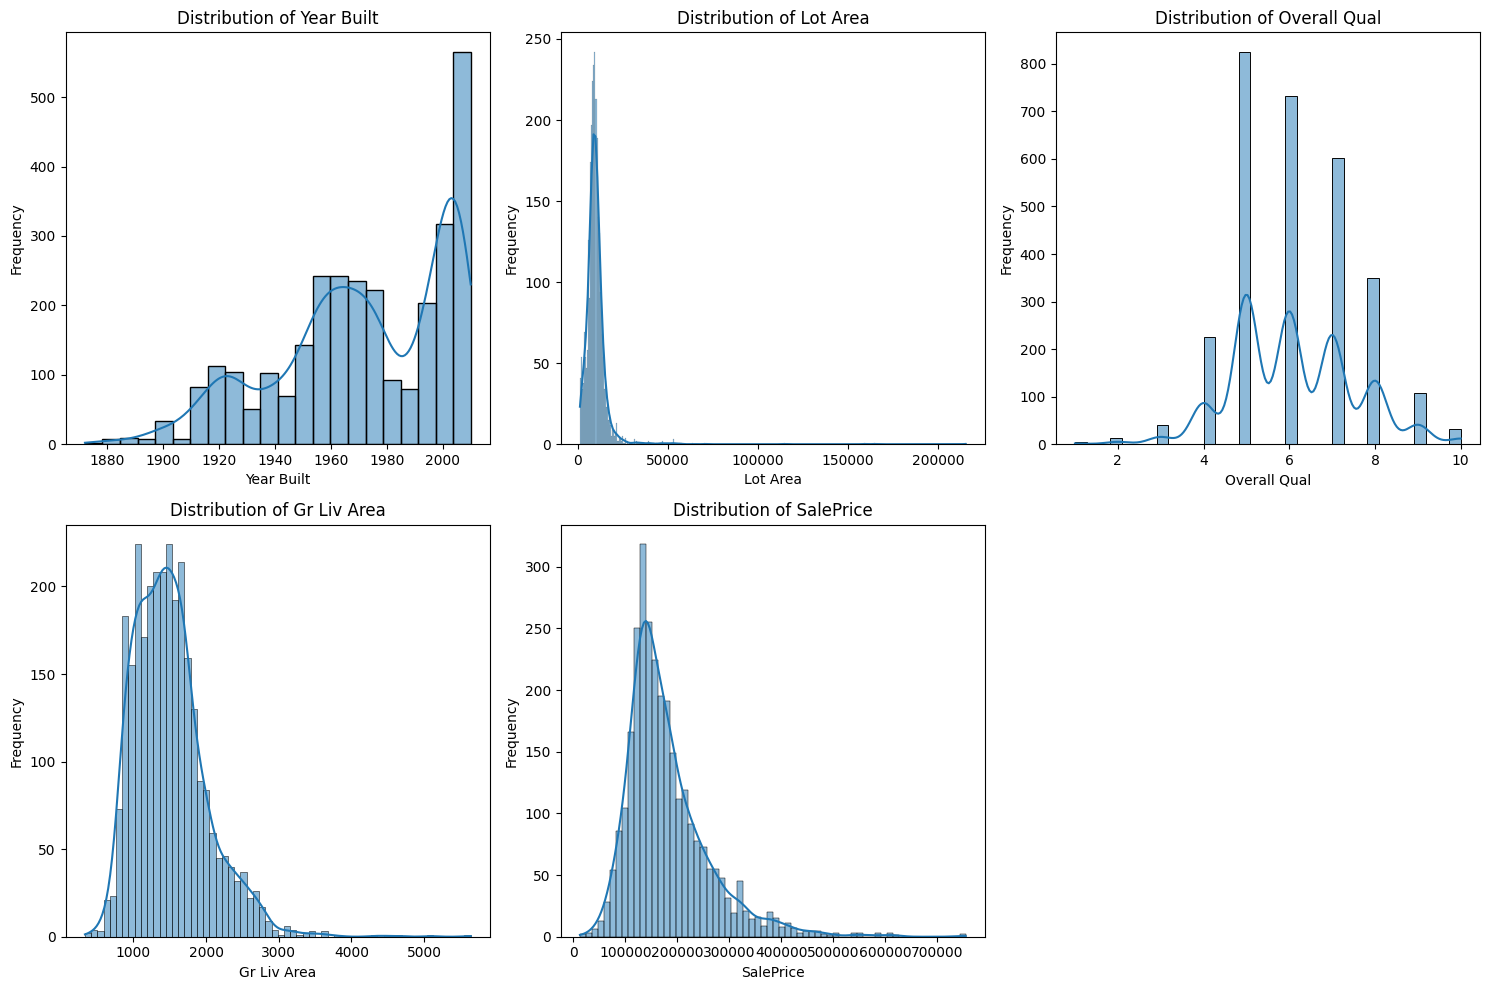

In [213]:
numerical_cols = ['Year Built', 'Lot Area', 'Overall Qual', 'Gr Liv Area', 'SalePrice']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

As someone who has spent over a decade in the trenches of Machine Learning, I’ve seen thousands of models fail because engineers applied "textbook" techniques like Binning without understanding the underlying signal.

In a professional production environment, we don't just "try" things. We look for specific **Statistical Signals**. Here is your Senior-level checklist for deciding if Binning is a "Go" or a "No-Go."

---

## 1. The "Signal" Check: When do I actually need Binning?

Before you write a single line of `KBinsDiscretizer`, you must look for these three signals. If none of these exist, Binning will likely be a waste of your time.

### A. The "Non-Linear/Non-Monotonic" Relationship
In Linear Regression, we assume that as $X$ increases, $Y$ increases (or decreases) at a constant rate.
* **The Signal:** Plot your feature against the Target (`SalePrice`). If you see a **"Plateau"** or a **"U-Shape"**, a straight line cannot capture it.
* **Why Binning Works:** It breaks that U-shape into separate segments, allowing the model to treat the "Bottom of the U" differently than the "Top."



### B. The "Outlier Sensitivity" (The Long Tail)
If you have a feature like `Lot Area` where 99% of houses are under 20,000 sq ft, but one house is 200,000 sq ft, that one house will "pull" the entire regression line toward it.
* **The Signal:** High **Kurtosis** (sharp peaks) and extreme **Skewness**.
* **Why Binning Works:** It puts all values above 20,000 into a single bucket called "Huge." The model no longer cares if it's 21k or 200k; it just knows it's "Huge."

### C. The "Noisy" Measurement
Sometimes the exact number is just "Noise." Does a house built in 1991 really differ from 1992? Probably not.
* **The Signal:** High variance in small intervals that doesn't change the outcome.
* **Why Binning Works:** It "smooths" the noise by grouping years into "Eras" (e.g., The 90s).

---

## 2. The 3 Things to Check *Before* Applying Binning

As a Senior Engineer, I never bin without checking these three "Health Metrics" first:

### 1. Feature Cardinality (Unique Values)
Count the unique values. If you have a column with only 5–10 unique values (like `Overall Qual` in Ames), it is **already binned**. Applying a binner on top of it is redundant and adds unnecessary complexity to your code.

### 2. Mutual Information (MI) Score
Run a Mutual Information test (`sklearn.feature_selection.mutual_info_regression`).
* **The Logic:** This measures how much "information" one variable gives you about another, regardless of whether the relationship is linear.
* **The Check:** If the MI score is high, but your **Correlation** ($R$) is low, it means there is a hidden non-linear pattern. **This is a massive signal that Binning will help.**



### 3. Data Density (Sample Size)
Binning requires **data volume**.
* **The Check:** If you create 20 bins but only have 500 rows, some bins might only have 5 houses in them.
* **The Danger:** Your model will "overfit" to those 5 houses. If those 5 houses happen to be expensive for a weird reason, the model will learn a false rule.

---

## 3. The "Death Knell" of Binning: Why it stays at 0.66

If you apply binning and see no improvement, it is usually because of **The Step-Function Problem.**

Linear Regression is a "Global" learner—it looks for one rule for the whole column. Binning turns a smooth feature into a **Step-Function**.
* If your 10 bins are `[0, 1, 2, 3...]`, you are telling the model that the distance between "Small" and "Medium" is the **exact same** as the distance between "Medium" and "Large."
* If that isn't true in the real world, the Linear Regression model will actually get **more confused**, not less.



---

## 4. Final Senior Advice: The "Ames" Strategy

For your specific project, don't bin everything. Follow this "Surgical" approach:

1.  **Bin the Time:** `Year Built` $\rightarrow$ Decades (Uniform binning).
2.  **Bin the Extremes:** `Lot Area` $\rightarrow$ Quantiles (to kill the outliers).
3.  **NEVER Bin the Core Signal:** `Gr Liv Area` $\rightarrow$ **Log Transform** instead. You want the model to see every single square foot of difference; don't hide it in a bucket.

### My Question for You:
Now that you have the Senior perspective, look at your `Overall Qual` column again. Knowing that it only has 10 possible values, do you think your `KBinsDiscretizer` was actually doing anything useful to it?